In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from scripts.compute_metrics import *
from scripts.recommender import *
import pandas as pd
import pandas as pd
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

processed_folder = project_root / "data" / "processed"
scripts_folder = project_root / "scripts"

In [2]:
nav = pd.read_csv(
    processed_folder /
    "nav_history_cleaned.csv"
)

fund_master = pd.read_csv(
    processed_folder /
    "fund_master_cleaned.csv"
)

performance = pd.read_csv(
    processed_folder /
    "scheme_performance_cleaned.csv"
)

portfolio = pd.read_csv(
    processed_folder /
    "portfolio_holdings_cleaned.csv"
)

investor = pd.read_csv(
    processed_folder /
    "investor_transactions_cleaned.csv"
)

In [3]:
nav["date"] = pd.to_datetime(
    nav["date"]
)

investor["transaction_date"] = pd.to_datetime(
    investor["transaction_date"]
)

In [4]:
returns = compute_daily_returns(nav)

returns.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [14]:
var_table = historical_var_cvar(nav)
var_table.to_csv(processed_folder / 'var_cvar_report.csv')
var_table.head(10)

,amfi_code,VaR_95,CVaR_95
4,101207,-0.023915,-0.030289
17,119095,-0.023284,-0.029690
22,119599,-0.023155,-0.030163
11,118634,-0.022810,-0.029940
39,149324,-0.021520,-0.028573
21,119598,-0.021502,-0.028444
16,119094,-0.016997,-0.022375
29,120842,-0.016950,-0.021251
2,100033,-0.016902,-0.021850
7,102886,-0.016857,-0.021771


var_table.sort_values(
    "VaR_95"
).head(10)

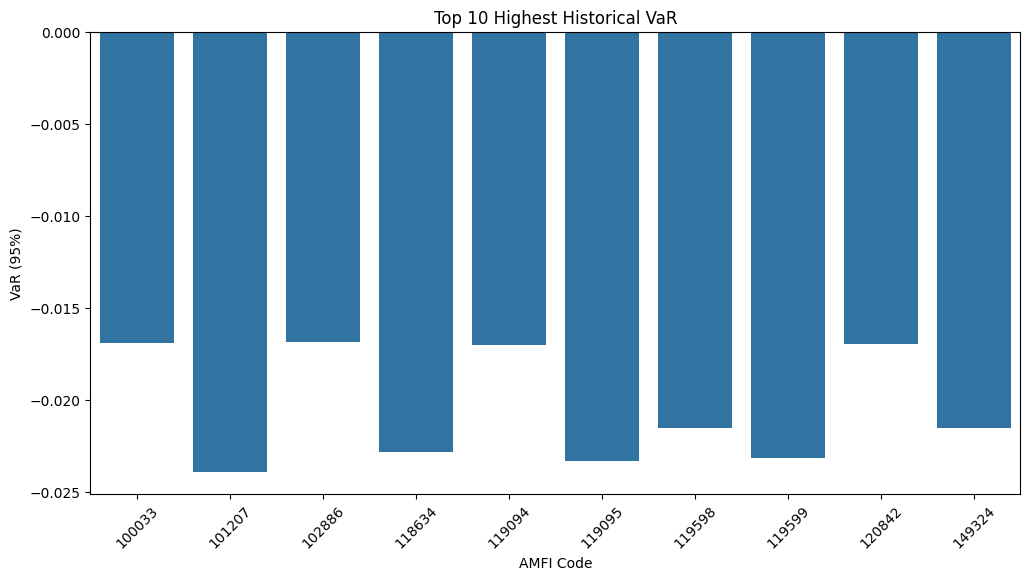

In [6]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=var_table.head(10),

    x="amfi_code",

    y="VaR_95"

)

plt.title(
    "Top 10 Highest Historical VaR"
)

plt.xlabel("AMFI Code")

plt.ylabel("VaR (95%)")

plt.xticks(rotation=45)

plt.show()

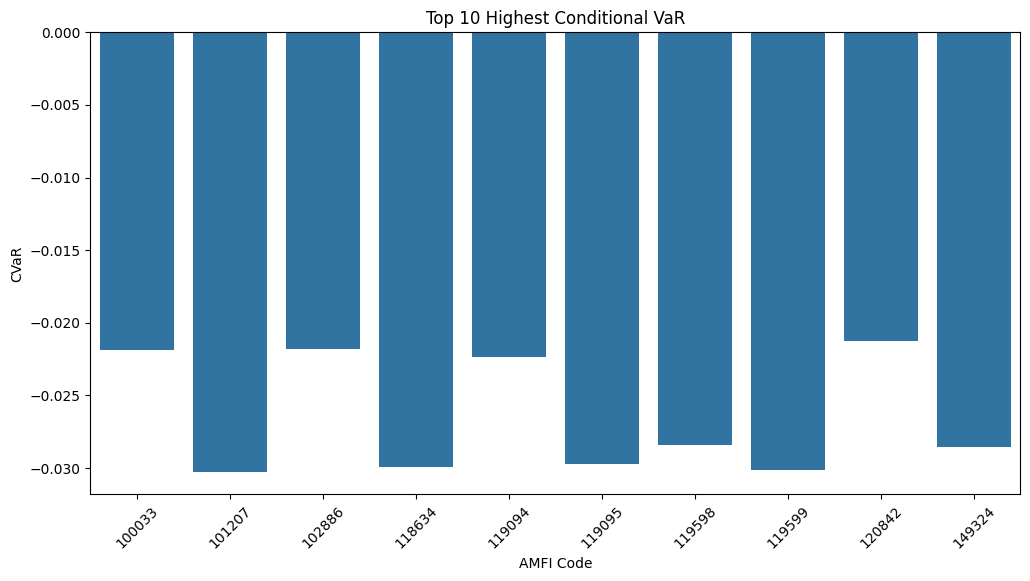

In [7]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=var_table.head(10),

    x="amfi_code",

    y="CVaR_95"

)

plt.title(
    "Top 10 Highest Conditional VaR"
)

plt.xlabel("AMFI Code")

plt.ylabel("CVaR")

plt.xticks(rotation=45)

plt.show()

In [8]:
rolling = rolling_sharpe(nav)

rolling.head()

,date,amfi_code,Rolling_Sharpe
0,2022-01-03,100016,NaN
1,2022-01-04,100016,NaN
2,2022-01-05,100016,NaN
3,2022-01-06,100016,NaN
4,2022-01-07,100016,NaN


In [9]:
rolling = rolling.merge(

    fund_master[

        [
            "amfi_code",
            "scheme_name"
        ]

    ],

    on="amfi_code",

    how="left"

)

In [10]:
top5 = (

    performance

    .sort_values(

        "return_3yr_pct",

        ascending=False

    )

    ["amfi_code"]

    .head(5)

    .tolist()

)

top5

[119598, 119599, 101207, 119095, 118634]

In [11]:
plot_rolling_sharpe(

    rolling,

    top5

)

In [12]:
fig = px.line(

    rolling[
        rolling["amfi_code"] == top5[0]
    ],

    x="date",

    y="Rolling_Sharpe",

    title="Rolling Sharpe Ratio"

)

fig.show()

In [13]:
rolling.groupby(

    "amfi_code"

)["Rolling_Sharpe"].agg(

    [

        "mean",

        "max",

        "min"

    ]

).round(2)

,mean,max,min
amfi_code,,,
100016,0.28,4.32,-4.66
100025,0.96,4.32,-3.30
100033,1.30,5.31,-2.86
101206,1.27,7.38,-2.38
101207,0.35,4.33,-3.27
101208,9.41,12.74,6.36
102885,1.18,3.93,-2.01
102886,0.11,3.53,-3.69
102887,0.99,5.89,-3.54
